In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from abc import ABC, abstractmethod

# ==========================================
# 1. 你的代码实现 (直接粘贴，保证原汁原味)
# ==========================================

class DplUHBase(nn.Module, ABC):
    """
    可微单位线基类 (S-Curve Difference Method + Causal Conv)
    """
    def __init__(self, max_lag, epsilon=1e-6):
        super().__init__()
        self.max_lag = int(max_lag)
        self.epsilon = epsilon
        
        # [修改] 生成整数时间点 0, 1, 2, ..., max_lag
        # 用来计算累积曲线 S(0), S(1), S(2)...
        self.register_buffer(
            "t_seq", 
            torch.arange(0, self.max_lag + 1, dtype=torch.float32).view(1, 1, -1)
        )

    def _get_t_seq(self, params):
        # 动态获取以匹配 device
        return torch.arange(0, self.max_lag + 1, device=params.device, dtype=params.dtype).view(1, 1, -1)

    @abstractmethod
    def get_s_curve(self, params, t_seq):
        """
        计算累积 S 曲线
        Returns S(t) for t in [0, 1, ..., max_lag]
        """
        raise NotImplementedError

    def forward(self, flux_in, params):
        if params.dim() == 1:
            params = params.unsqueeze(-1)
        batch_size, time_steps = flux_in.shape

        # 1. 获取时间序列 0, 1, ..., max_lag
        t_seq = self._get_t_seq(params)

        # 2. 计算 S-Curve [Batch, 1, max_lag+1]
        s_curve = self.get_s_curve(params, t_seq)
        
        # 3. 差分计算权重 w(t) = S(t) - S(t-1)
        # s_curve[..., 1:] 取索引 1..L (对应 t=1..L)
        # s_curve[..., :-1] 取索引 0..L-1 (对应 t=0..L-1)
        # 结果长度为 max_lag
        raw_weights = s_curve[..., 1:] - s_curve[..., :-1]
        
        # 4. 归一化 (可选，S-Curve 理论上最终趋于1，但截断可能导致不足1)
        sum_w = raw_weights.sum(dim=-1, keepdim=True)
        norm_weights = raw_weights / (sum_w + self.epsilon)

        # 5. 翻转 + 卷积 (手动左填充)
        flipped_weights = torch.flip(norm_weights, dims=[-1])
        
        x = flux_in.view(1, batch_size, time_steps)
        pad_size = self.max_lag - 1
        padded_x = F.pad(x, (pad_size, 0))

        flux_out = F.conv1d(
            input=padded_x, 
            weight=flipped_weights, 
            groups=batch_size,
            padding=0
        )

        return flux_out.view(batch_size, time_steps)

class DplHalf1(DplUHBase):
    def get_s_curve(self, params, t_seq):
        # params: x4 (Batch, 1)
        x4 = torch.clamp(params, min=1e-3)
        
        # ratio = t / x4
        ratio = t_seq / x4.unsqueeze(-1)
        
        # 公式: S(t) = (t/x4)^2.5,  if t < x4
        #       S(t) = 1,          if t >= x4
        s_curve = torch.clamp(ratio, max=1.0).pow(2.5)
        
        return s_curve

class DplFull2(DplUHBase):
    def get_s_curve(self, params, t_seq):
        # params: x4 (Batch, 1)
        x4 = torch.clamp(params, min=1e-3)
        
        # ratio = t / x4
        ratio = t_seq / x4.unsqueeze(-1)
        
        # 分段计算 S(t)
        # 1. 前半段: t <= x4 -> ratio <= 1
        s_part1 = 0.5 * ratio.pow(2.5)
        
        # 2. 后半段: x4 < t < 2*x4 -> 1 < ratio < 2
        # 公式: 1 - 0.5 * (2 - ratio)^2.5
        # clamp(..., min=0) 是为了防止 ratio > 2 时出现负数底数
        term_b = torch.clamp(2.0 - ratio, min=0.0)
        s_part2 = 1.0 - 0.5 * term_b.pow(2.5)
        
        # 3. 组合
        s_curve = torch.where(ratio <= 1.0, s_part1, s_part2)
        
        # 确保最大为 1
        s_curve = torch.clamp(s_curve, max=1.0)
        
        return s_curve

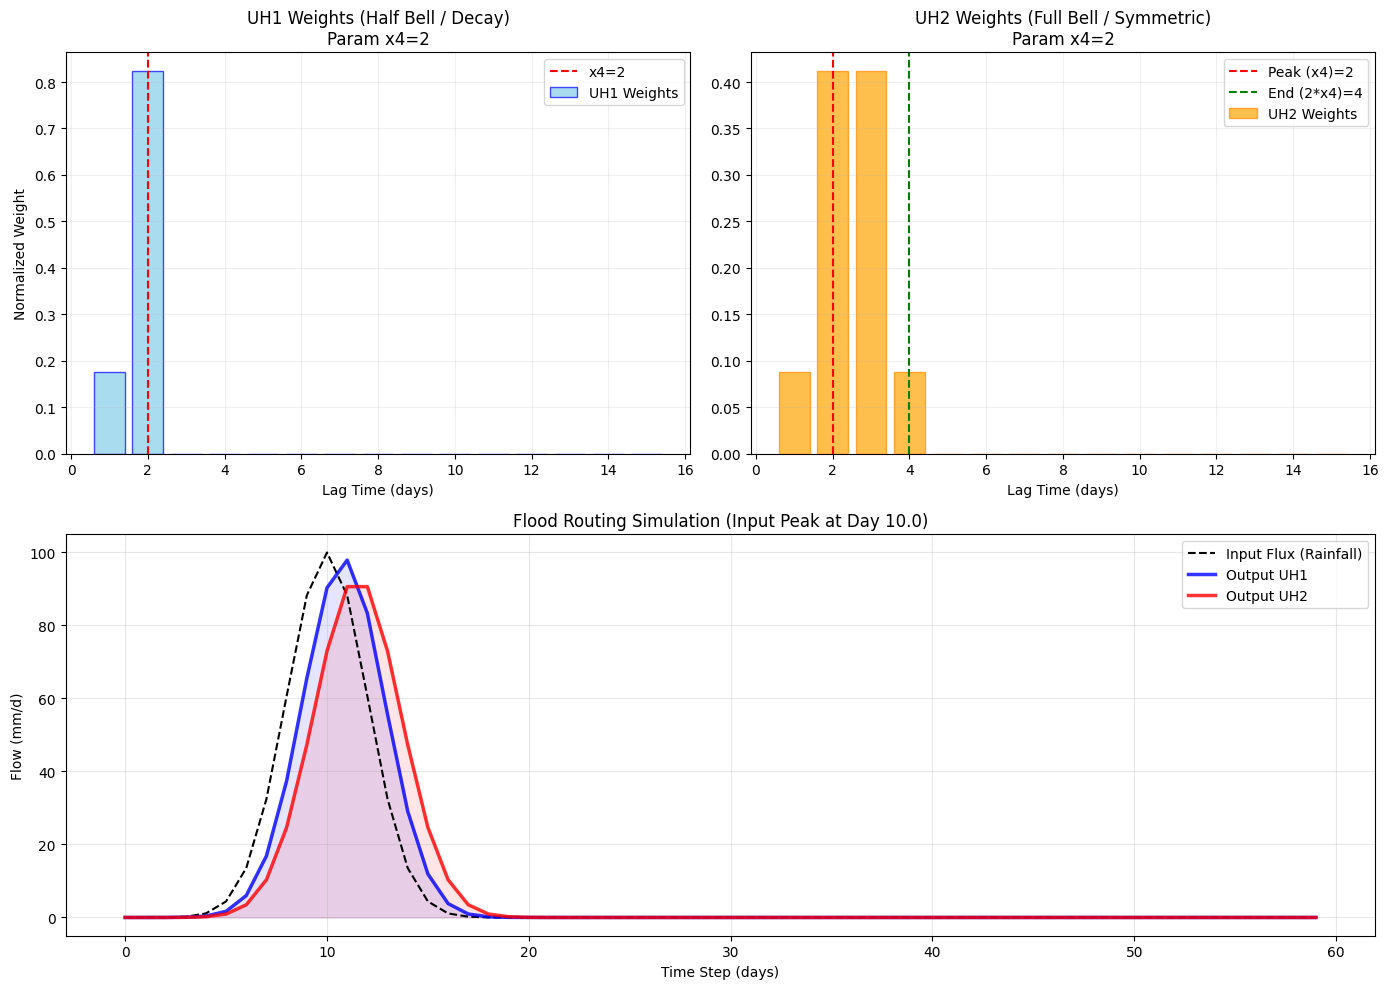

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 假设你已经定义了 DplUHBase, DplHalf1, DplFull2 
# (请确保上面的类定义代码已运行或导入)
# ==========================================

# ==========================================
# 3. 测试脚本 (S-Curve 差分版)
# ==========================================

# --- 1. 设置 ---
max_lag = 15     # 单位线最大长度
n_steps = 60     # 模拟总时长

# [参数设定]
# x4 = 6.0 天
# 对 UH1 (Half): 响应持续到 x4 (6天)
# 对 UH2 (Full): 响应持续到 2*x4 (12天)
x4_val = 2 
x4_param = torch.tensor([x4_val], dtype=torch.float32).view(1, 1) # Batch=1

# --- 2. 构造输入: 高斯型洪水 ---
t = torch.linspace(0, n_steps-1, n_steps)
peak_time = 10.0 # 洪峰在第10天
width = 2.0
# 生成模拟产流量 (Effective Rainfall)
input_flow = 100 * torch.exp(-(t - peak_time)**2 / (2 * width**2))
input_flow = input_flow.view(1, n_steps) # Shape: [Batch, Time]

# --- 3. 初始化模型 ---
model_uh1 = DplHalf1(max_lag=max_lag)
model_uh2 = DplFull2(max_lag=max_lag)

# --- 4. 运行模型 (Forward Pass) ---
with torch.no_grad():
    # 4.1 直接获取汇流后的结果
    # 这里会自动执行: S-Curve -> Diff -> Norm -> Flip -> Pad -> Conv
    out_flow1 = model_uh1(input_flow, x4_param)
    out_flow2 = model_uh2(input_flow, x4_param)
    
    # 4.2 [关键] 手动提取权重用于画图 (Visualization Only)
    # 新逻辑是 S-Curve 差分，所以我们需要手动构造 t_seq 来计算
    
    # 构造时间序列 [0, 1, 2, ..., max_lag]
    t_seq_plot = torch.arange(0, max_lag + 1, dtype=torch.float32).view(1, 1, -1)
    
    # --- 计算 UH1 权重 ---
    # 1. 获取累积曲线 S(t)
    s_curve1 = model_uh1.get_s_curve(x4_param, t_seq_plot)
    # 2. 差分计算权重: w[t] = S[t] - S[t-1]
    raw_w1 = s_curve1[..., 1:] - s_curve1[..., :-1]
    # 3. 归一化 (模拟 forward 中的行为)
    w1_norm = raw_w1 / (raw_w1.sum(dim=-1, keepdim=True) + 1e-6)
    
    # --- 计算 UH2 权重 ---
    s_curve2 = model_uh2.get_s_curve(x4_param, t_seq_plot)
    raw_w2 = s_curve2[..., 1:] - s_curve2[..., :-1]
    w2_norm = raw_w2 / (raw_w2.sum(dim=-1, keepdim=True) + 1e-6)

# --- 5. 绘图 ---
fig = plt.figure(figsize=(14, 10))

# 数据转 numpy
t_np = t.numpy()
in_np = input_flow[0].numpy()
out1_np = out_flow1[0].numpy()
out2_np = out_flow2[0].numpy()

# 提取 batch 0 的权重
w1_np = w1_norm[0, 0].numpy() # shape (Lag,)
w2_np = w2_norm[0, 0].numpy()

# -------------------------------------------------------
# 子图 1: UH1 权重 (Half Bell)
# -------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
# 物理时间步是 1, 2, ..., max_lag (代表 0-1, 1-2 时段的响应)
lag_axis = np.arange(1, max_lag + 1) 

ax1.bar(lag_axis, w1_np, color='skyblue', edgecolor='blue', alpha=0.7, label='UH1 Weights')
# 理论截止点 x4
ax1.axvline(x=x4_val, color='red', linestyle='--', label=f'x4={x4_val}')
ax1.set_title(f"UH1 Weights (Half Bell / Decay)\nParam x4={x4_val}")
ax1.set_xlabel("Lag Time (days)")
ax1.set_ylabel("Normalized Weight")
ax1.legend()
ax1.grid(True, alpha=0.2)

# -------------------------------------------------------
# 子图 2: UH2 权重 (Full Bell)
# -------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)
ax2.bar(lag_axis, w2_np, color='orange', edgecolor='darkorange', alpha=0.7, label='UH2 Weights')
# 理论峰值点 x4
ax2.axvline(x=x4_val, color='red', linestyle='--', label=f'Peak (x4)={x4_val}')
# 理论截止点 2*x4
ax2.axvline(x=2*x4_val, color='green', linestyle='--', label=f'End (2*x4)={2*x4_val}')
ax2.set_title(f"UH2 Weights (Full Bell / Symmetric)\nParam x4={x4_val}")
ax2.set_xlabel("Lag Time (days)")
ax2.legend()
ax2.grid(True, alpha=0.2)

# -------------------------------------------------------
# 子图 3: 洪水汇流过程 (Routing Results)
# -------------------------------------------------------
ax3 = fig.add_subplot(2, 1, 2)
# 输入降雨
ax3.plot(t_np, in_np, 'k--', linewidth=1.5, label='Input Flux (Rainfall)')

# UH1 输出 (通常响应较快)
ax3.plot(t_np, out1_np, 'b-', linewidth=2.5, alpha=0.8, label='Output UH1')
ax3.fill_between(t_np, out1_np, alpha=0.1, color='blue')

# UH2 输出 (通常有明显的滞后和坦化)
ax3.plot(t_np, out2_np, 'r-', linewidth=2.5, alpha=0.8, label='Output UH2')
ax3.fill_between(t_np, out2_np, alpha=0.1, color='red')

ax3.set_title(f"Flood Routing Simulation (Input Peak at Day {peak_time})")
ax3.set_xlabel("Time Step (days)")
ax3.set_ylabel("Flow (mm/d)")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

In [11]:
# --- 设置 ---
# 因为 x4 设为 10，UH2 长度为 20，为了安全 max_lag 设为 25
max_lag = 25 
n_steps = 100

# 设定参数 x4 = 10.0 天 (比之前更长，平滑效果更明显)
x4_val = 10.0 
x4_param = torch.tensor([x4_val]).view(1, 1)

# --- 构造输入: 多峰洪水 (Multi-Peak) ---
t = torch.linspace(0, n_steps-1, n_steps)

# Peak 1: 第15天，尖锐的小洪水
peak1 = 50 * torch.exp(-(t - 15)**2 / (2 * 1.5**2))

# Peak 2: 第45天，主要的大洪水 (宽峰)
peak2 = 120 * torch.exp(-(t - 45)**2 / (2 * 4.0**2))

# Peak 3: 第60天，余震 (紧跟在主峰后面，测试叠加效应)
peak3 = 60 * torch.exp(-(t - 60)**2 / (2 * 2.0**2))

input_flow = (peak1 + peak2 + peak3).view(1, n_steps)

# --- 初始化模型 ---
model_uh1 = DplHalf1(max_lag=max_lag)
model_uh2 = DplFull2(max_lag=max_lag)

# --- 运行模型 ---
with torch.no_grad():
    out_flow1, weights1 = model_uh1(input_flow, x4_param)
    out_flow2, weights2 = model_uh2(input_flow, x4_param)

# --- 绘图 ---
fig = plt.figure(figsize=(15, 10))

# 转 numpy
t_np = t.numpy()
in_np = input_flow[0].numpy()
out1_np = out_flow1[0].numpy()
out2_np = out_flow2[0].numpy()
w1_np = weights1[0, 0].numpy()
w2_np = weights2[0, 0].numpy()

# 1. 第一行：权重可视化
ax1 = fig.add_subplot(2, 2, 1)
lag_axis = np.arange(1, max_lag + 1)
ax1.bar(lag_axis, w1_np, color='skyblue', edgecolor='blue', alpha=0.7, label='UH1 Weights')
ax1.axvline(x=x4_val, color='red', linestyle='--', label=f'x4={x4_val}')
ax1.set_title(f"UH1 Weights (Half Bell)\nAccumulates until day {int(x4_val)}")
ax1.set_xlabel("Lag Time (days)")
ax1.set_ylabel("Weight")
ax1.legend()

ax2 = fig.add_subplot(2, 2, 2)
ax2.bar(lag_axis, w2_np, color='orange', edgecolor='darkorange', alpha=0.7, label='UH2 Weights')
ax2.axvline(x=x4_val, color='red', linestyle='--', label=f'Peak at {x4_val}')
ax2.axvline(x=2*x4_val, color='green', linestyle='--', label=f'End at {2*x4_val}')
ax2.set_title(f"UH2 Weights (Full Bell)\nSpreads over {int(2*x4_val)} days")
ax2.set_xlabel("Lag Time (days)")
ax2.legend()

# 2. 第二行：洪水汇流过程
ax3 = fig.add_subplot(2, 1, 2)

# 输入流 (黑色虚线)
ax3.plot(t_np, in_np, 'k--', linewidth=1.5, alpha=0.6, label='Input (Production)')
ax3.fill_between(t_np, in_np, color='gray', alpha=0.1) # 填充阴影更直观

# UH1 输出 (蓝色)
ax3.plot(t_np, out1_np, 'b-', linewidth=2.5, alpha=0.8, label='UH1 Output (Delay)')

# UH2 输出 (红色)
ax3.plot(t_np, out2_np, 'r-', linewidth=2.5, alpha=0.9, label='UH2 Output (Routing)')

# 标注峰值时刻
ax3.text(15, 60, "Peak 1", ha='center', color='black')
ax3.text(45, 130, "Peak 2 (Main)", ha='center', color='black')
ax3.text(60, 70, "Peak 3", ha='center', color='black')

ax3.set_title(f"100-Day Multi-Peak Simulation (x4 = {x4_val} days)")
ax3.set_xlabel("Time Step (days)")
ax3.set_ylabel("Flow (mm/d)")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: not enough values to unpack (expected 2, got 1)